# CIFAR-100 Baseline Core Pipeline

仅保留主线：CauchyCNN 在 4 组组合下训练与对比。


In [1]:
import os
import random
import sys
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm import tqdm

sys.path.append(os.path.abspath("../../src"))
from cauchy_res_mixer import CauchyCNN, ImprovedCauchyCNN, evaluate, train_one_epoch

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cuda


In [2]:
@dataclass
class Config:
    batch_size: int = 128
    epochs: int = 5
    lr: float = 1e-3
    weight_decay: float = 1e-4
    num_workers: int = 2
    base_channels: int = 64

cfg_debug = Config(
    batch_size=64,
    epochs=1,
    lr=1e-3,
    weight_decay=1e-4,
    num_workers=0,
    base_channels=32,
)

cfg_full = Config(
    batch_size=128,
    epochs=50,
    lr=1e-3,
    weight_decay=1e-4,
    num_workers=2,
    base_channels=64,
)

debug = False
cfg = cfg_debug if debug else cfg_full

experiment_grid = [
    ("standard", "relu"),
    ("standard", "cauchy"),
    ("cauchy", "relu"),
    ("cauchy", "cauchy"),
]

cfg

Config(batch_size=128, epochs=50, lr=0.001, weight_decay=0.0001, num_workers=2, base_channels=64)

In [3]:
mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_ds = datasets.CIFAR100(root="./data", train=True, download=True, transform=train_transform)
test_ds = datasets.CIFAR100(root="./data", train=False, download=True, transform=test_transform)

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=(device.type == "cuda"),
)

test_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=(device.type == "cuda"),
)

num_classes = len(train_ds.classes)
print(f"Train={len(train_ds)}, Test={len(test_ds)}, Classes={num_classes}")


/data1/linjiangtao2024/cauchy_activation/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train=50000, Test=10000, Classes=100


In [4]:
def run_experiment(model_ctor, train_loader, test_loader, num_classes):
    criterion = nn.CrossEntropyLoss()
    results = {}

    experiment_bar = tqdm(experiment_grid, desc="Experiments", leave=True)
    for residual_mode, activation_mode in experiment_bar:
        key = f"{residual_mode}_{activation_mode}"
        experiment_bar.set_postfix_str(key)
        model = model_ctor(
            num_classes=num_classes,
            base_channels=cfg.base_channels,
            activation_mode=activation_mode,
            residual_mode=residual_mode,
        ).to(device)

        optimizer = torch.optim.AdamW(
            model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay
        )

        history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
        epoch_bar = tqdm(range(cfg.epochs), desc=f"{key}", leave=False)
        for epoch in epoch_bar:
            tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
            te_loss, te_acc = evaluate(model, test_loader, criterion, device)
            history["train_loss"].append(tr_loss)
            history["train_acc"].append(tr_acc)
            history["test_loss"].append(te_loss)
            history["test_acc"].append(te_acc)
            epoch_bar.set_postfix_str(
                f"train_acc={tr_acc:.4f}, test_acc={te_acc:.4f}"
            )
            print(f"[{key}] epoch {epoch+1:02d}/{cfg.epochs} | train_acc={tr_acc:.4f} test_acc={te_acc:.4f}")

        results[key] = {
            "residual_mode": residual_mode,
            "activation_mode": activation_mode,
            "history": history,
            "final_test_acc": history["test_acc"][-1],
        }

    return results

In [5]:
results = run_experiment(CauchyCNN, train_loader, test_loader, num_classes)


Experiments:   0%|          | 0/4 [00:00<?, ?it/s, standard_relu]

[standard_relu] epoch 01/50 | train_acc=0.0773 test_acc=0.1213


[standard_relu] epoch 02/50 | train_acc=0.1693 test_acc=0.2176


[standard_relu] epoch 03/50 | train_acc=0.2709 test_acc=0.3161


[standard_relu] epoch 04/50 | train_acc=0.3586 test_acc=0.3825


...

[cauchy_cauchy] epoch 47/50 | train_acc=0.5181 test_acc=0.4566


[cauchy_cauchy] epoch 48/50 | train_acc=0.5232 test_acc=0.4468


[cauchy_cauchy] epoch 49/50 | train_acc=0.5191 test_acc=0.4592


Experiments: 100%|██████████| 4/4 [2:01:27<00:00, 1821.99s/it, cauchy_cauchy]

[cauchy_cauchy] epoch 50/50 | train_acc=0.5260 test_acc=0.4596


In [6]:
def plot_results(results):
    epochs_axis = np.arange(1, cfg.epochs + 1)

    plt.figure(figsize=(13, 5))
    plt.subplot(1, 2, 1)
    for k, v in results.items():
        plt.plot(epochs_axis, v["history"]["test_loss"], label=k)
    plt.title("Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8)

    plt.subplot(1, 2, 2)
    for k, v in results.items():
        plt.plot(epochs_axis, v["history"]["test_acc"], label=k)
    plt.title("Test Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    ranked = sorted(results.items(), key=lambda kv: kv[1]["final_test_acc"], reverse=True)
    labels = [k for k, _ in ranked]
    vals = [v["final_test_acc"] for _, v in ranked]

    plt.figure(figsize=(8, 4))
    bars = plt.bar(labels, vals)
    plt.ylim(0, 1)
    plt.title("Final Test Accuracy Ranking")
    plt.ylabel("Accuracy")
    plt.xticks(rotation=20)
    for b, val in zip(bars, vals):
        plt.text(b.get_x() + b.get_width() / 2, val + 0.01, f"{val:.3f}", ha="center", va="bottom")
    plt.tight_layout()
    plt.show()


{'exp': 'standard_relu', 'residual_mode': 'standard', 'activation_mode': 'relu', 'final_test_acc': 0.7029}
{'exp': 'cauchy_relu', 'residual_mode': 'cauchy', 'activation_mode': 'relu', 'final_test_acc': 0.6909}
{'exp': 'standard_cauchy', 'residual_mode': 'standard', 'activation_mode': 'cauchy', 'final_test_acc': 0.4705}
{'exp': 'cauchy_cauchy', 'residual_mode': 'cauchy', 'activation_mode': 'cauchy', 'final_test_acc': 0.4596}


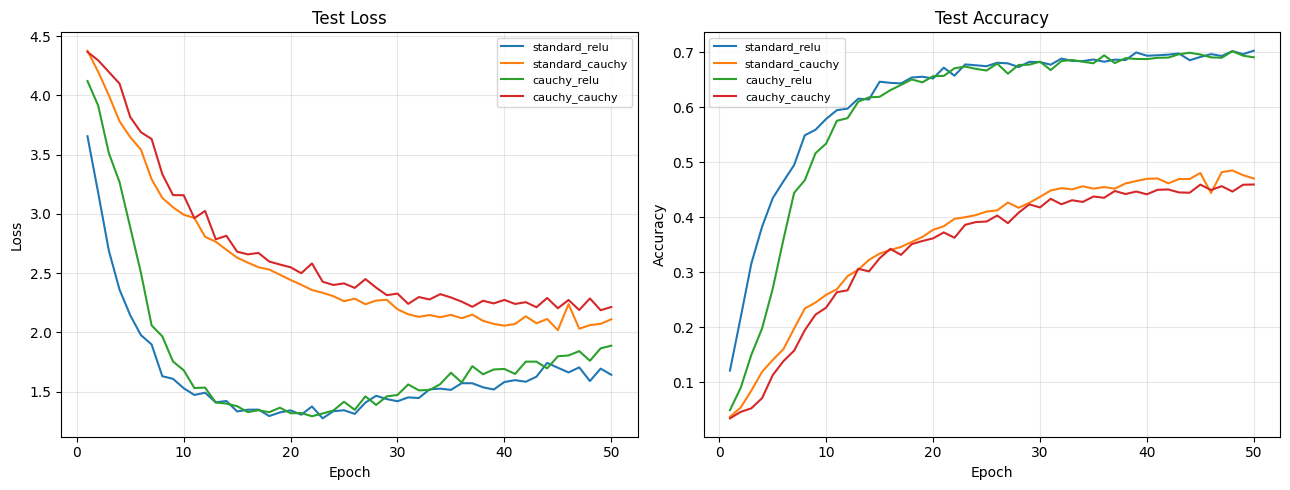

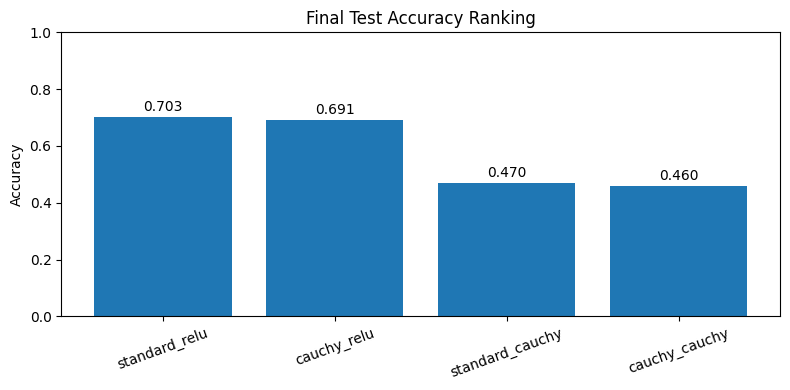

In [7]:
rows = [
    {
        "exp": k,
        "residual_mode": v["residual_mode"],
        "activation_mode": v["activation_mode"],
        "final_test_acc": v["final_test_acc"],
    }
    for k, v in results.items()
]
rows = sorted(rows, key=lambda x: x["final_test_acc"], reverse=True)
for r in rows:
    print(r)
plot_results(results)